```{index} Support settlement; Class exercise
```
```{index} Stiffness influences; Class exercise
```


(lesson8.2)=
# Lesson October 23th

During today's lesson you'll work on a complex exercise on the topic of Stiffness discontinuities and Support settlement. Please ask your questions regarding the [homework](homework8.2) as well!

## Exercise Support settlement

Given the following structure.

```{figure} intro_data/structure.svg
:align: center
```

1. Find the moment distribution for $n=1$


````{admonition} Solution assignment 1
:class: tip, dropdown

```{figure} intro_data/M-line.svg
:align: center
```

````

## Exercise Stiffness discontinuities

2. Find the moment distribution for $n=0$
3. Find the moment distribution for $n \to \infty$
4. Find the support reactions for an arbitrary value for $n$

````{admonition} Solution assignment 2
:class: tip, dropdown

```{figure} intro_data/M-line-2.svg
:align: center
```

````

````{admonition} Solution assignment 3
:class: tip, dropdown

```{figure} intro_data/M-line-3.svg
:align: center
```
````

````{admonition} Solution assignment 4
:class: tip, dropdown

- $A_{\rm{v}} = \cfrac{25n}{4n+2}$
- $B_{\rm{v}} = -\cfrac{75n}{4n+2}$
- $C_{\rm{v}} = \cfrac{75n}{4n+2}$
- $D_{\rm{v}} = -\cfrac{25n}{4n+2}$

```{figure} intro_data/steunpuntszetting.svg
:align: center
```

````

In [27]:
import sympy as sym

EI = sym.nsimplify(25e3/3*10)
display(EI.evalf())
w = sym.nsimplify(0.025)

M_B, M_C = sym.symbols('M_B M_C')

eq1 = sym.Eq(-M_B * 10 / 3 / EI + w / 10 ,0)
M_B_1 = sym.solve(eq1, M_B)[0]

A_v_1 = M_B_1 / 10
B_v_1 = - A_v_1 * 3
C_v_1 = - B_v_1
D_v_1 = - A_v_1
display(A_v_1.evalf(), B_v_1.evalf(), C_v_1.evalf(), D_v_1.evalf())

w_mid = M_B_2 * 10**2 / EI / 16 + w
display(w_mid.evalf())
display(w_mid.evalf() - w)

83333.3333333333

6.25000000000000

-18.7500000000000

18.7500000000000

-6.25000000000000

0.0334375000000000

0.00843750000000000

In [28]:
M_B, M_C = sym.symbols('M_B M_C')
n = sym.symbols('n', positive=True)

phi_B_AB = M_B * 10 / EI / 3
phi_B_BC = - M_B * 10 / EI / 3 / n + w / 10 - M_C * 10 / EI / 6 / n 
phi_C_BC = M_C * 10 / EI / 3 / n + w / 10 + M_B * 10 / EI / 6 / n
phi_C_CD = - M_C * 10 / EI / 3

eq1 = sym.Eq(phi_B_AB, phi_B_BC)
eq2 = sym.Eq(phi_C_CD, phi_C_BC)

sol = sym.solve((eq1, eq2), (M_B, M_C))

# Express M_C as a function of M_B using eq2
M_B_expr = sym.solve(eq1, M_B)[0]#.expand()
display(M_B_expr)
M_B_expr_2 = sym.solve(eq2, M_B)[0]#.expand()
display(M_B_expr_2)
tussenstap = sym.Eq(M_B_expr - M_B_expr_2, 0)
display(tussenstap)
display(tussenstap.simplify())

display(sol[M_B], sol[M_C])
display(sol[M_B].evalf(), sol[M_C].evalf())

(-M_C + 125*n)/(2*(n + 1))

-2*M_C*n - 2*M_C - 125*n

Eq(2*M_C*n + 2*M_C + 125*n + (-M_C + 125*n)/(2*(n + 1)), 0)

Eq((-M_C + 125*n + 2*(n + 1)*(2*M_C*n + 2*M_C + 125*n))/(2*(n + 1)), 0)

125*n/(2*n + 1)

-125*n/(2*n + 1)

125.0*n/(2.0*n + 1.0)

-125.0*n/(2.0*n + 1.0)

In [29]:
A_v, M_C = sym.symbols('A_v M_C')
n = sym.symbols('n', positive=True)

w_A = w * 2 - A_v * 10**3 / EI / 3 - A_v * 10 * 10 / 3 / EI / n * 10 - M_C * 10 / 6 / EI / n * 10
phi_C_BC = M_C * 10 / EI / 3 / n + w / 10 + A_v * 10 * 10 / EI / 6 / n
phi_C_CD = - M_C * 10 / EI / 3

eq1 = sym.Eq(w_A, w)
display(eq1)
eq2 = sym.Eq(phi_C_CD, phi_C_BC)
display(eq2)

sol = sym.solve((eq1, eq2), (A_v, M_C))

A_v_sol = sol[A_v].simplify()
M_C_sol = sol[M_C].simplify()

display(A_v_sol, M_C_sol)

Eq(-A_v/250 - A_v/(250*n) - M_C/(5000*n) + 1/20, 1/40)

Eq(-M_C/25000, A_v/(5000*n) + M_C/(25000*n) + 1/400)

25*n/(2*(2*n + 1))

-125*n/(2*n + 1)

In [30]:
A_v, D_v = sym.symbols('A_v D_v')
n = sym.symbols('n', positive=True)

M_B = A_v * 10
M_C = D_v * 10
display(M_B, M_C)
phi_B = w / 10 - M_B * 10 / EI / n / 3 - M_C * 10 / EI / n / 6
display(phi_B.evalf())
phi_C = w / 10 + M_B * 10 / EI / n / 6 + M_C * 10 / EI / n / 3
display(phi_C.evalf())

w_A = w - A_v * 10**3 / EI / 3 + phi_B * 10
w_D = - D_v * 10**3 / EI / 3  - phi_C * 10

eq1 = sym.Eq(w_A, w)
eq2 = sym.Eq(w_D, 0)

display(eq1.evalf())
display(eq2.evalf())


sol = sym.solve((eq1, eq2), (A_v, D_v))

A_v_sol = sol[A_v].simplify()
D_v_sol = sol[D_v].simplify()

display(A_v_sol, D_v_sol)

M_B_sol = A_v_sol * 10
M_C_sol = D_v_sol * 10

B_v_sol = - M_B_sol / 10 - M_B_sol * 2 / 10
display(B_v_sol)
C_v_sol = -B_v_sol

display(M_B_sol.subs(n,1e20).evalf(), M_C_sol.subs(n,1))

10*A_v

10*D_v

-0.0004*A_v/n - 0.0002*D_v/n + 0.0025

0.0002*A_v/n + 0.0004*D_v/n + 0.0025

Eq(-0.004*A_v - 0.004*A_v/n - 0.002*D_v/n + 0.05, 0.025)

...

25*n/(2*(2*n + 1))

-25*n/(4*n + 2)

-75*n/(2*(2*n + 1))

62.5000000000000

-125/3

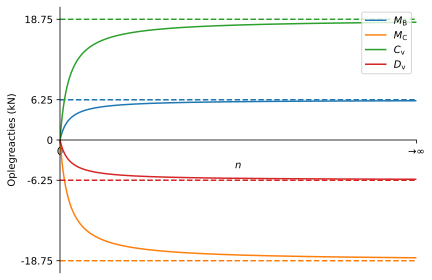

In [37]:
import numpy as np
%config InlineBackend.figure_formats = ['svg']
n_max = 20
n_eval = np.linspace(0, n_max, 1000)
A_v_eval = sym.lambdify(n, A_v_sol)
B_v_eval = sym.lambdify(n, B_v_sol)
C_v_eval = sym.lambdify(n, C_v_sol)
D_v_eval = sym.lambdify(n, D_v_sol)

import matplotlib.pyplot as plt
plt.plot(n_eval, A_v_eval(n_eval), label=r'$M_{\rm{B}}$')
# get color of last line
line = plt.gca().lines[-1]
color = line.get_color()
plt.plot([0, n_max], [6.25,6.25], '--',color=color)

plt.plot(n_eval, B_v_eval(n_eval), label=r'$M_{\rm{C}}$')
line = plt.gca().lines[-1]
color = line.get_color()
plt.plot([0, n_max], [-18.75,-18.75], '--',color=color)

plt.plot(n_eval, C_v_eval(n_eval), label=r'$C_{\rm{v}}$')
line = plt.gca().lines[-1]
color = line.get_color()
plt.plot([0, n_max], [18.75,18.75], '--',color=color)

plt.plot(n_eval, D_v_eval(n_eval), label=r'$D_{\rm{v}}$')
line = plt.gca().lines[-1]
color = line.get_color()
plt.plot([0, n_max], [-6.25,-6.25], '--',color=color)

plt.xlim([0,n_max])
plt.xlabel('$n$')
plt.ylabel('Oplegreacties (kN)')
ax = plt.gca()
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')
ax.spines['bottom'].set_position('zero')
ax.spines['left'].set_position('zero')
# add yticks at 3/16 and -3/16+1/4
plt.yticks([-18.75,-6.25,0,6.25,18.75],('-18.75','-6.25','0','6.25','18.75'))
plt.xticks([0, n_max], ['0', '$ →  \infty$'])
plt.legend(loc='upper right');

#plt.gcf().patch.set_alpha(0)
#ax.set_facecolor('none')
plt.savefig('steunpuntszetting.svg', transparent=True, bbox_inches='tight')